# 02 - Exploratory Data Analysis: Feature-Level Visualization

**Milestone 1 — Part 2.B**: Generate feature-level visualizations to understand distributions, detect outliers, and build intuition about the dataset.

## Objectives
- Generate histograms for **all** features (overview grid)
- Deep-dive into the **target** (`taxvaluedollarcnt`) and **3 other interesting features**
- Use appropriate plot types: histograms, boxplots (numerical), bar plots (categorical)
- Identify distributions (normal, skewed, exponential) and outliers

## Expected Outcomes
| Deliverable | Description |
|---|---|
| All-feature histogram grid | Quick overview of every column's distribution |
| 4 deep-dive plots | Target + 3 features with histograms + boxplots |
| Outlier observations | Notes on features with extreme values |
| Distribution labels | Normal / skewed / bimodal / etc. per explored feature |

## Mapping to Milestone 1
- **Part 2.B** — Feature-level visualization, discussion question 2.B

---

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

def dollar_format(x, pos):
    return f'${x:,.0f}'

df = pd.read_csv("zillow_dataset.csv")
print(f"Shape: {df.shape}")

Shape: (77613, 55)


## 1a. Categorical Histogram Grid

Quick overview — use a large `figsize` and `layout=(-1, m)` to get `m` columns with auto rows.

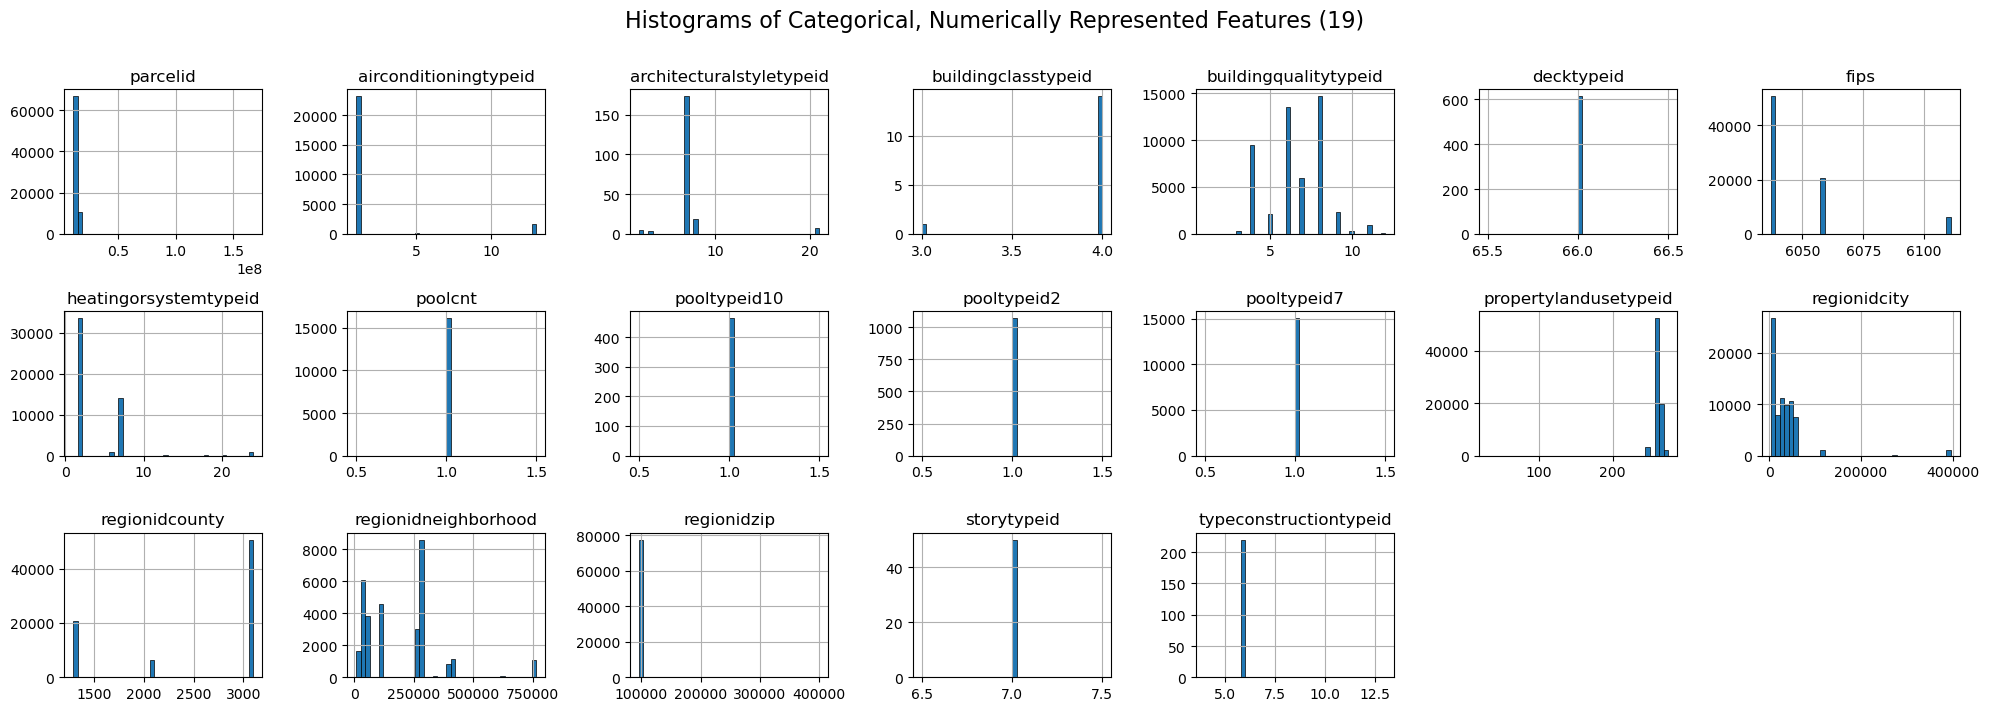

In [2]:
# Categorical histograms for non-objects:

categorical = ['parcelid', 'airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid', 'buildingqualitytypeid', 'decktypeid', 'fips', 'hashottuborspa', 'heatingorsystemtypeid', 'poolcnt', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidneighborhood', 'regionidzip', 'storytypeid', 'typeconstructiontypeid', 'fireplaceflag', 'taxdelinquencyflag']

fig = df[categorical].hist(figsize=(20, 7), layout=(-1, 7), bins=40, edgecolor='black', linewidth=0.5)
plt.suptitle("Histograms of Categorical, Numerically Represented Features (19)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

**Non-boolean features**: parcelid, airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, buildingqualitytypeid, fips, heatingorsystemtypeid, propertylandusetypeid, regionidcity, regionidcounty, regionidneighborhood, regionidzip

- Most non-boolean categorical features have extremely skewed distributions, with one dominant value making up 80%+ of all entries (e.g., airconditioningtypeid is overwhelmingly value 1, heatingorsystemtypeid is dominated by value 2).
- regionidcity and regionidneighborhood have relatively flat distributions across many unique values, suggesting they capture genuine geographic variation.
- propertycountylandusecode is heavily dominated by a few codes, with a long tail of rare codes.

**Boolean**: poolcnt, pooltypeid10, pooltypeid2, pooltypeid7

- Boolean but odd format: decktypeid and storytypeid look boolean but are marked at 66 and 7 instead of 1. This likely reflects encoding from the original data source rather than a meaningful numeric scale.
- All 5 object-type categorical columns (hashottuborspa, propertycountylandusecode, propertyzoningdesc, fireplaceflag, taxdelinquencyflag) are extremely sparse — most rows are NaN with a single non-null value type.

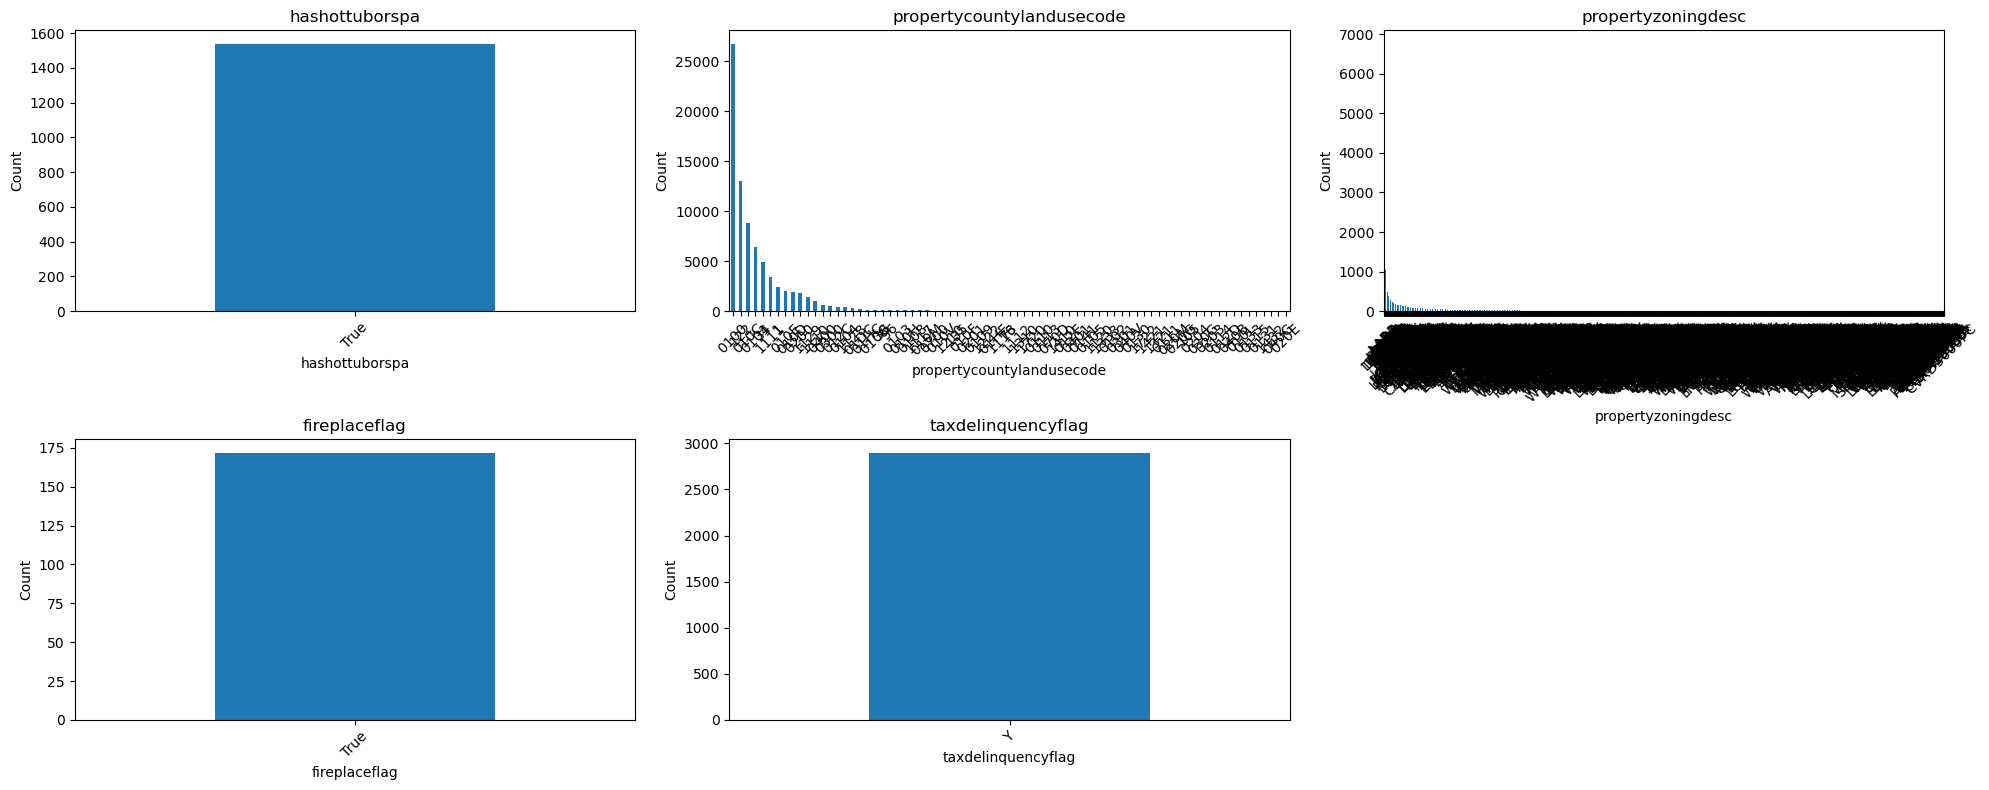

In [3]:
# Categorical bar plots for objects:

# data:
forbar = ['hashottuborspa','propertycountylandusecode','propertyzoningdesc','fireplaceflag','taxdelinquencyflag']


# plot:
n = len(forbar)
cols = 3
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()
for i, col in enumerate(forbar):
    df[col].value_counts().plot(kind='bar', ax=axes[i], title=col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
# hide unused subplots:
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

**Non-boolean features**: parcelid, airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, buildingqulitytypeid, fips, heatingorsystemtypeid, propertylandusetypeid, regionidcity, regionidcounty, regionidneighborhood, regionidzip

**Boolean**: poolcnt, pooltypeid10, pooltypeid2, pooltypeid7
Boolean but odd format: decktypeid and storytypeid look boolean but marked at 66 and 7 instead of 1.

## 1b. Numerical Histogram Grid, Plus


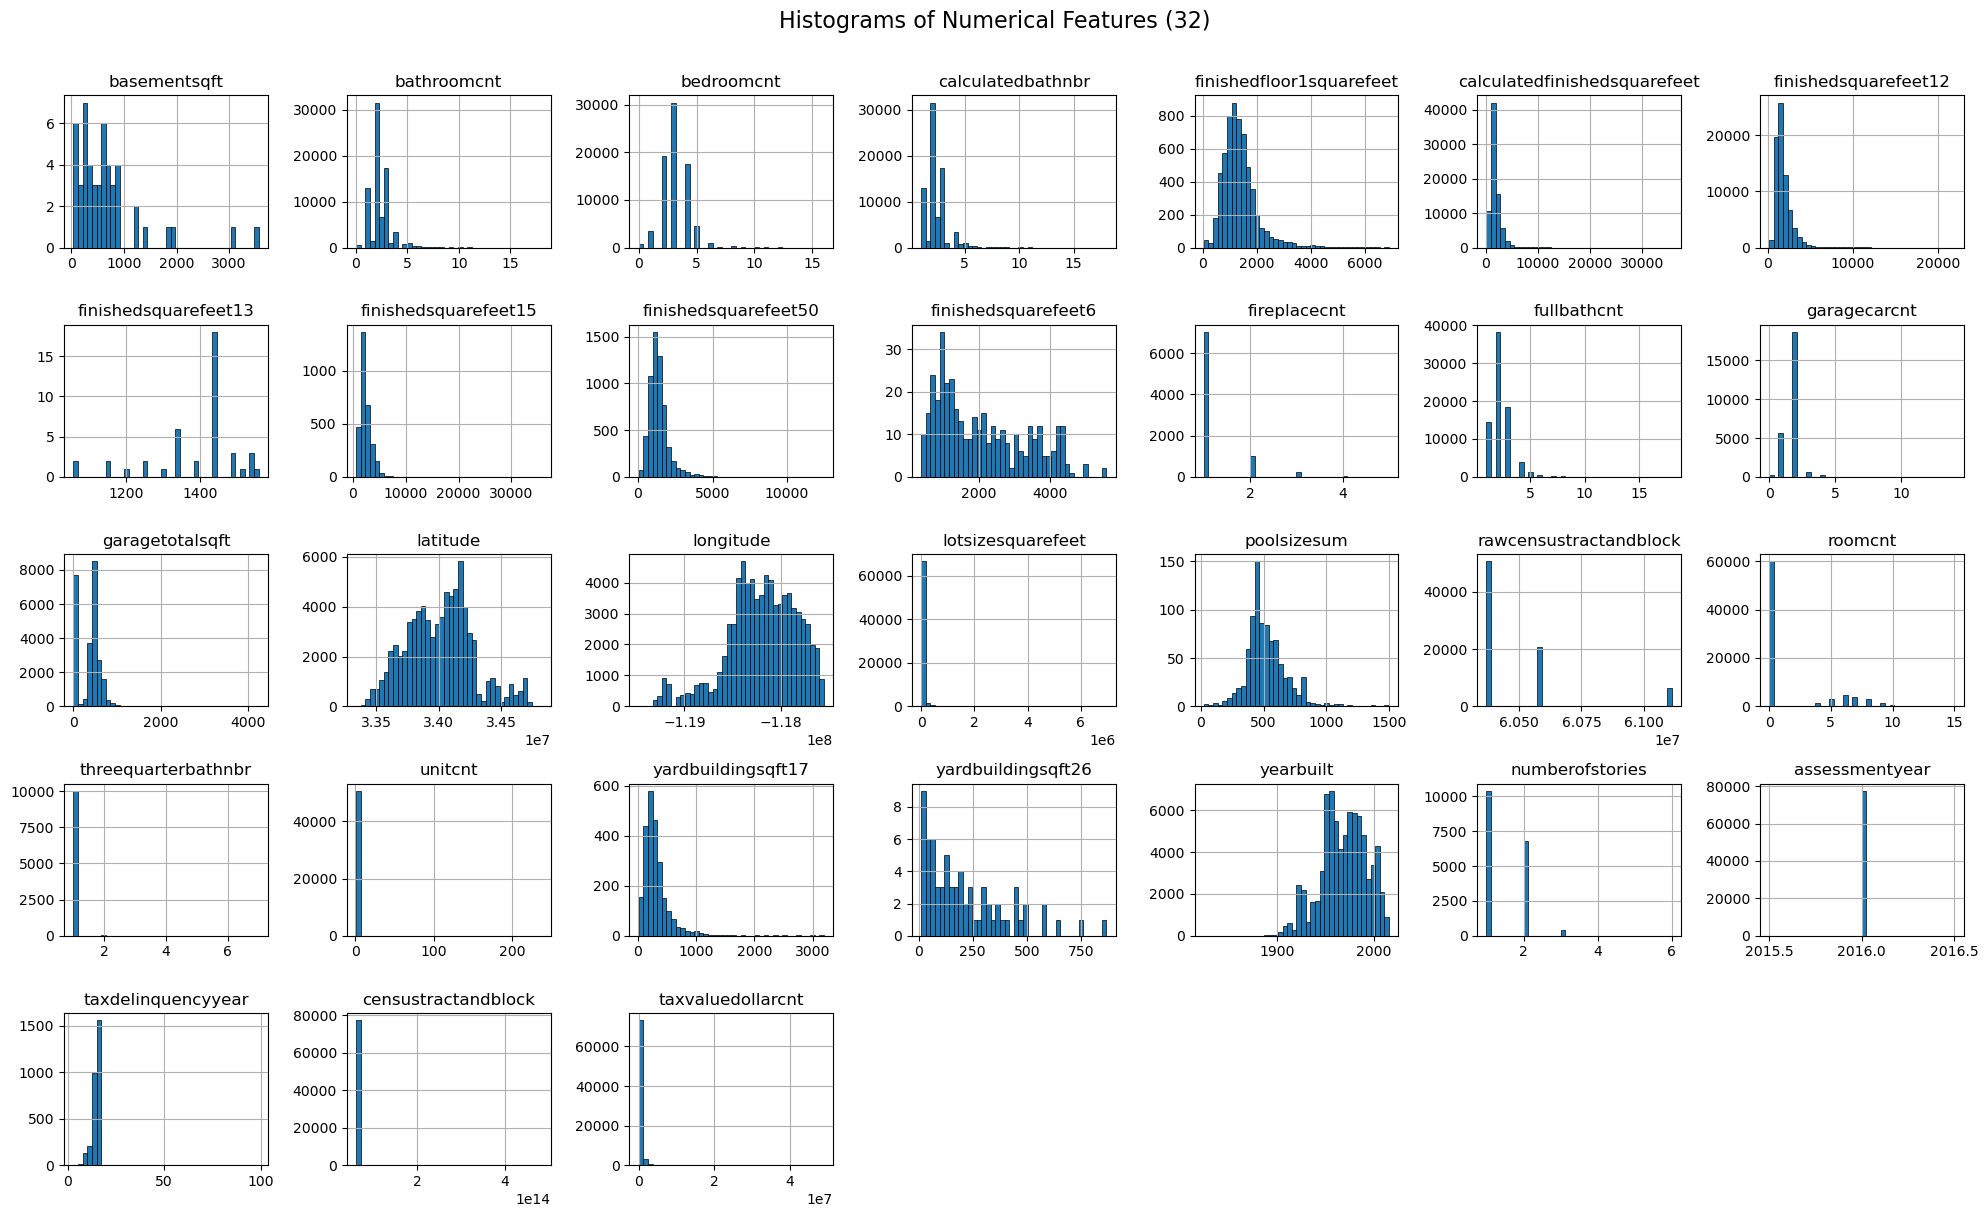

In [4]:
numerical =  ['basementsqft', 'bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'finishedfloor1squarefeet', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'fullbathcnt', 'garagecarcnt', 'garagetotalsqft', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolsizesum', 'rawcensustractandblock', 'roomcnt', 'threequarterbathnbr', 'unitcnt', 'yardbuildingsqft17', 'yardbuildingsqft26', 'yearbuilt', 'numberofstories', 'assessmentyear', 'taxdelinquencyyear', 'censustractandblock', 'taxvaluedollarcnt']

fig = df[numerical].hist(figsize=(20,12), layout=(-1, 7), bins=40, edgecolor='black', linewidth=0.5)
plt.suptitle("Histograms of Numerical Features (32)", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

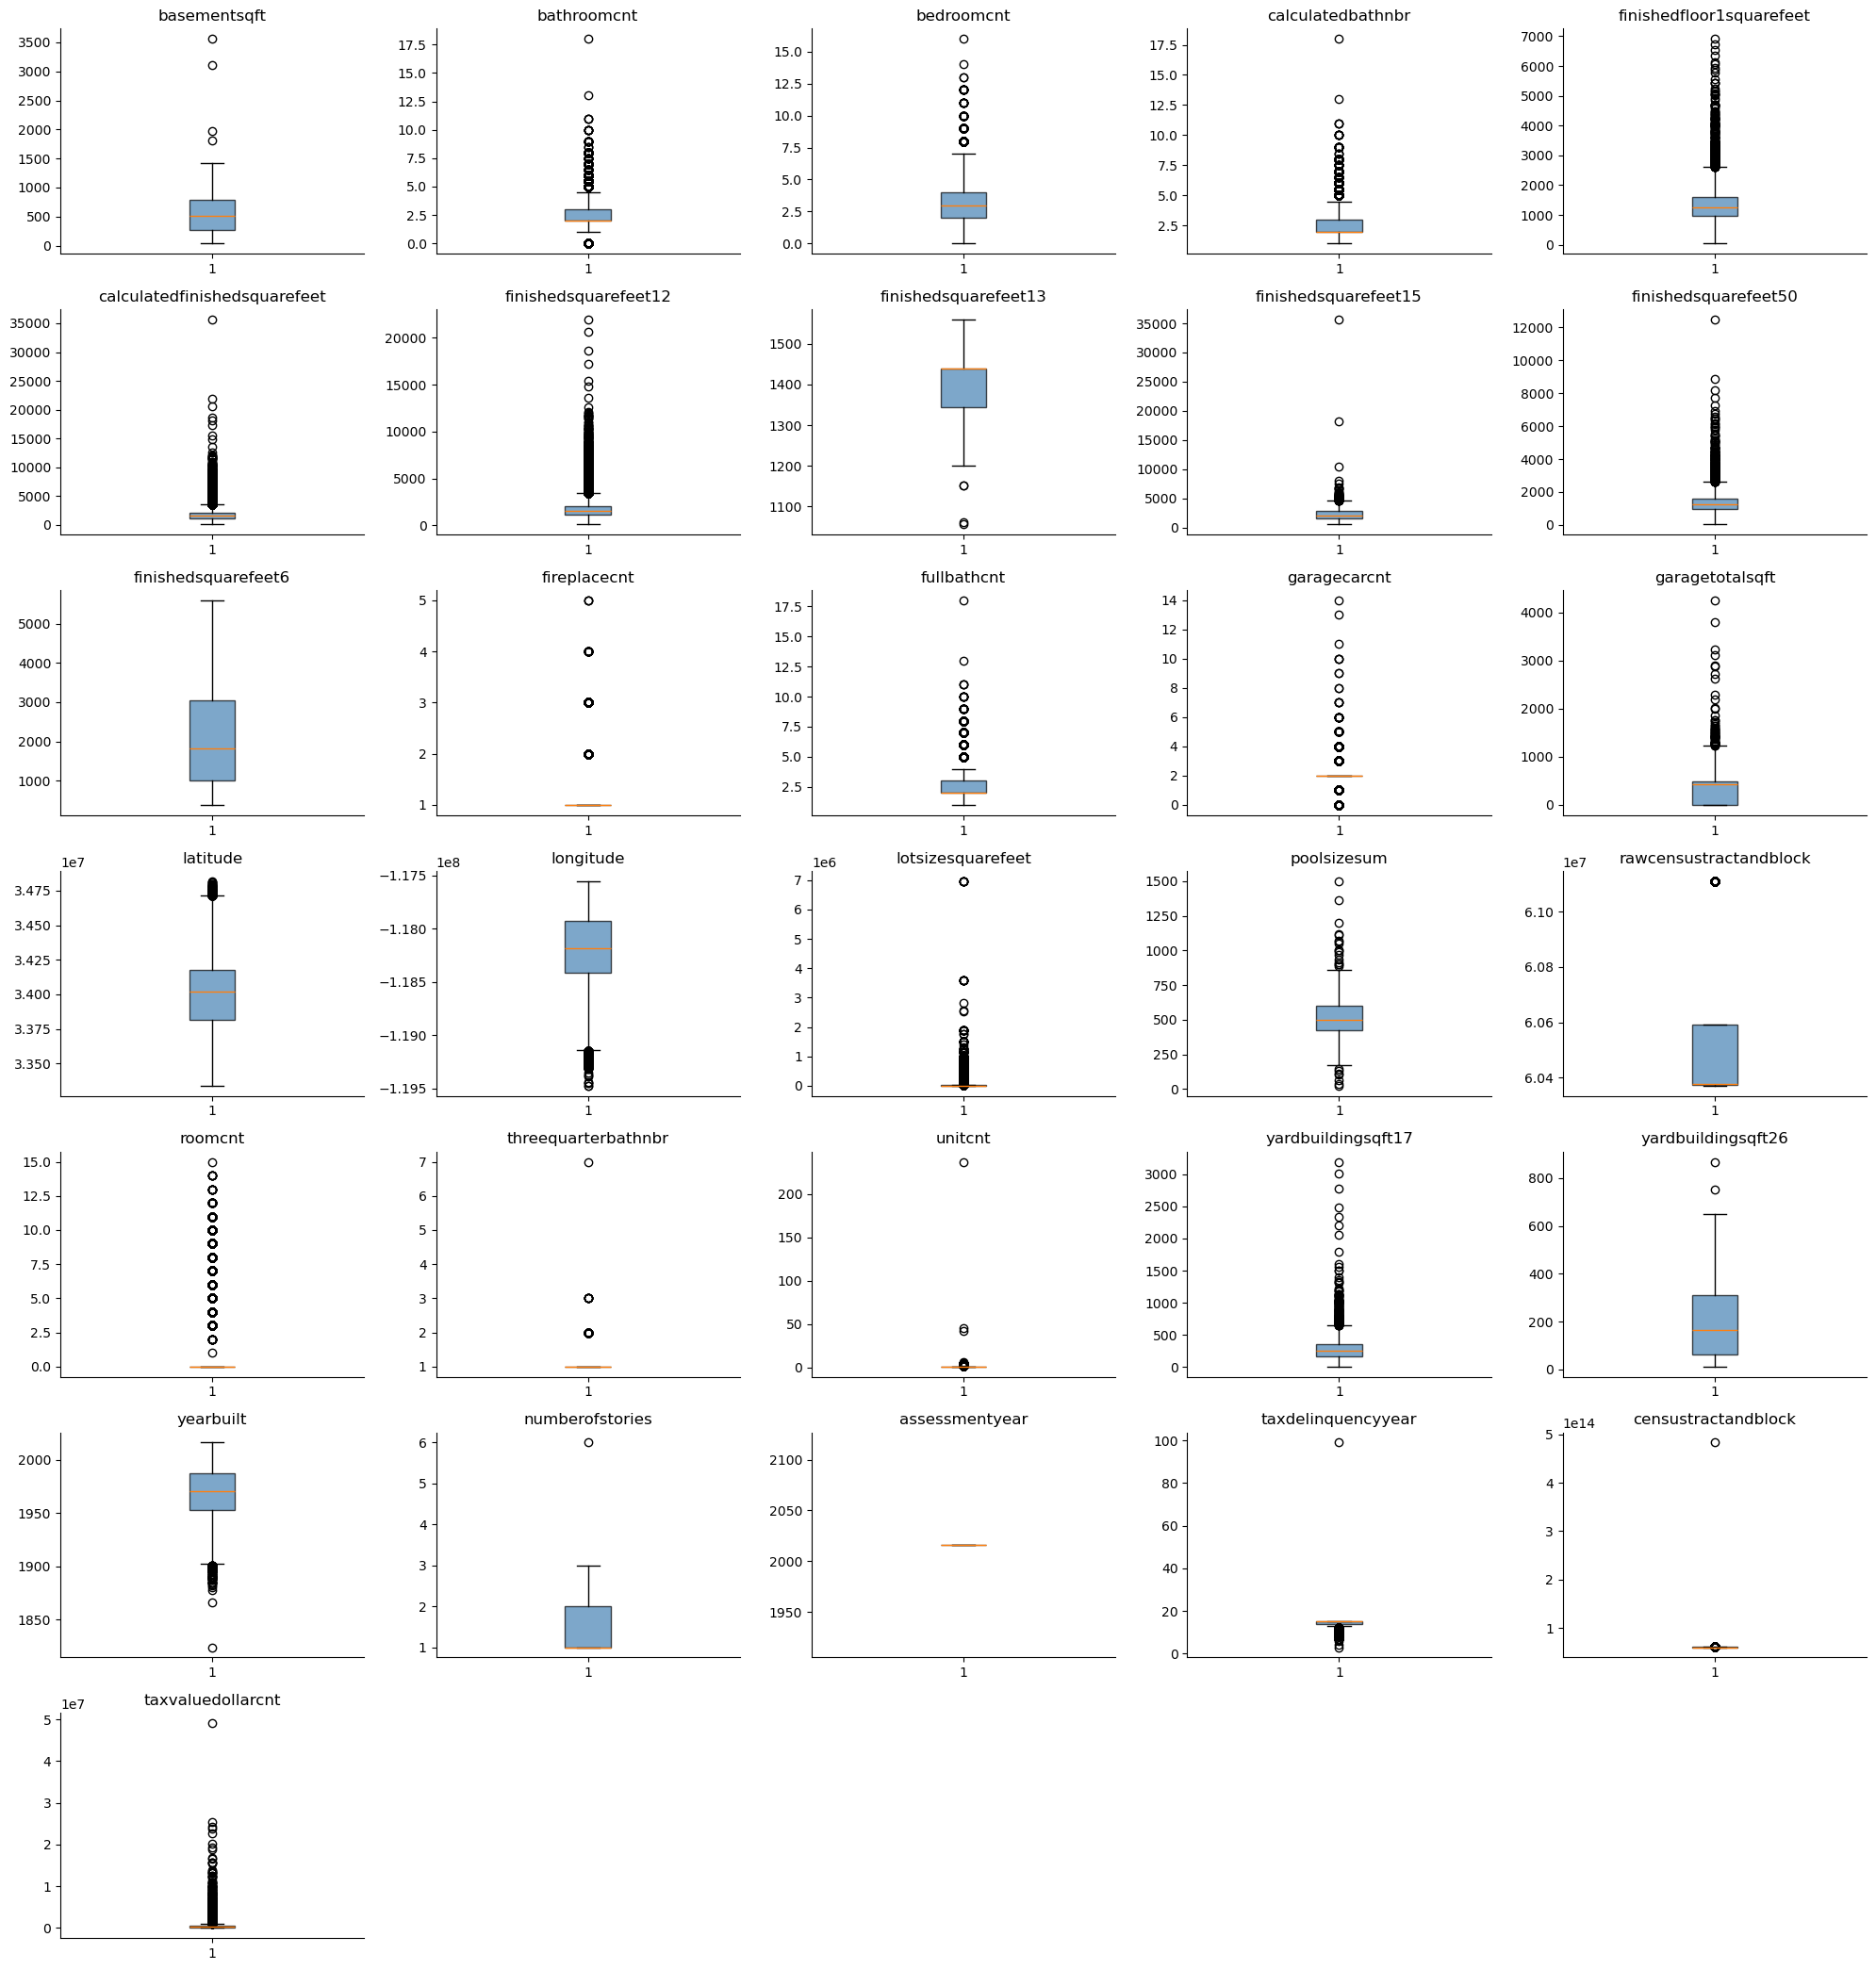

In [5]:
# Numerical boxplots: 
n = len(numerical)
cols = 5
rows = -(-n // cols)  # ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()

for i, col in enumerate(numerical):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()

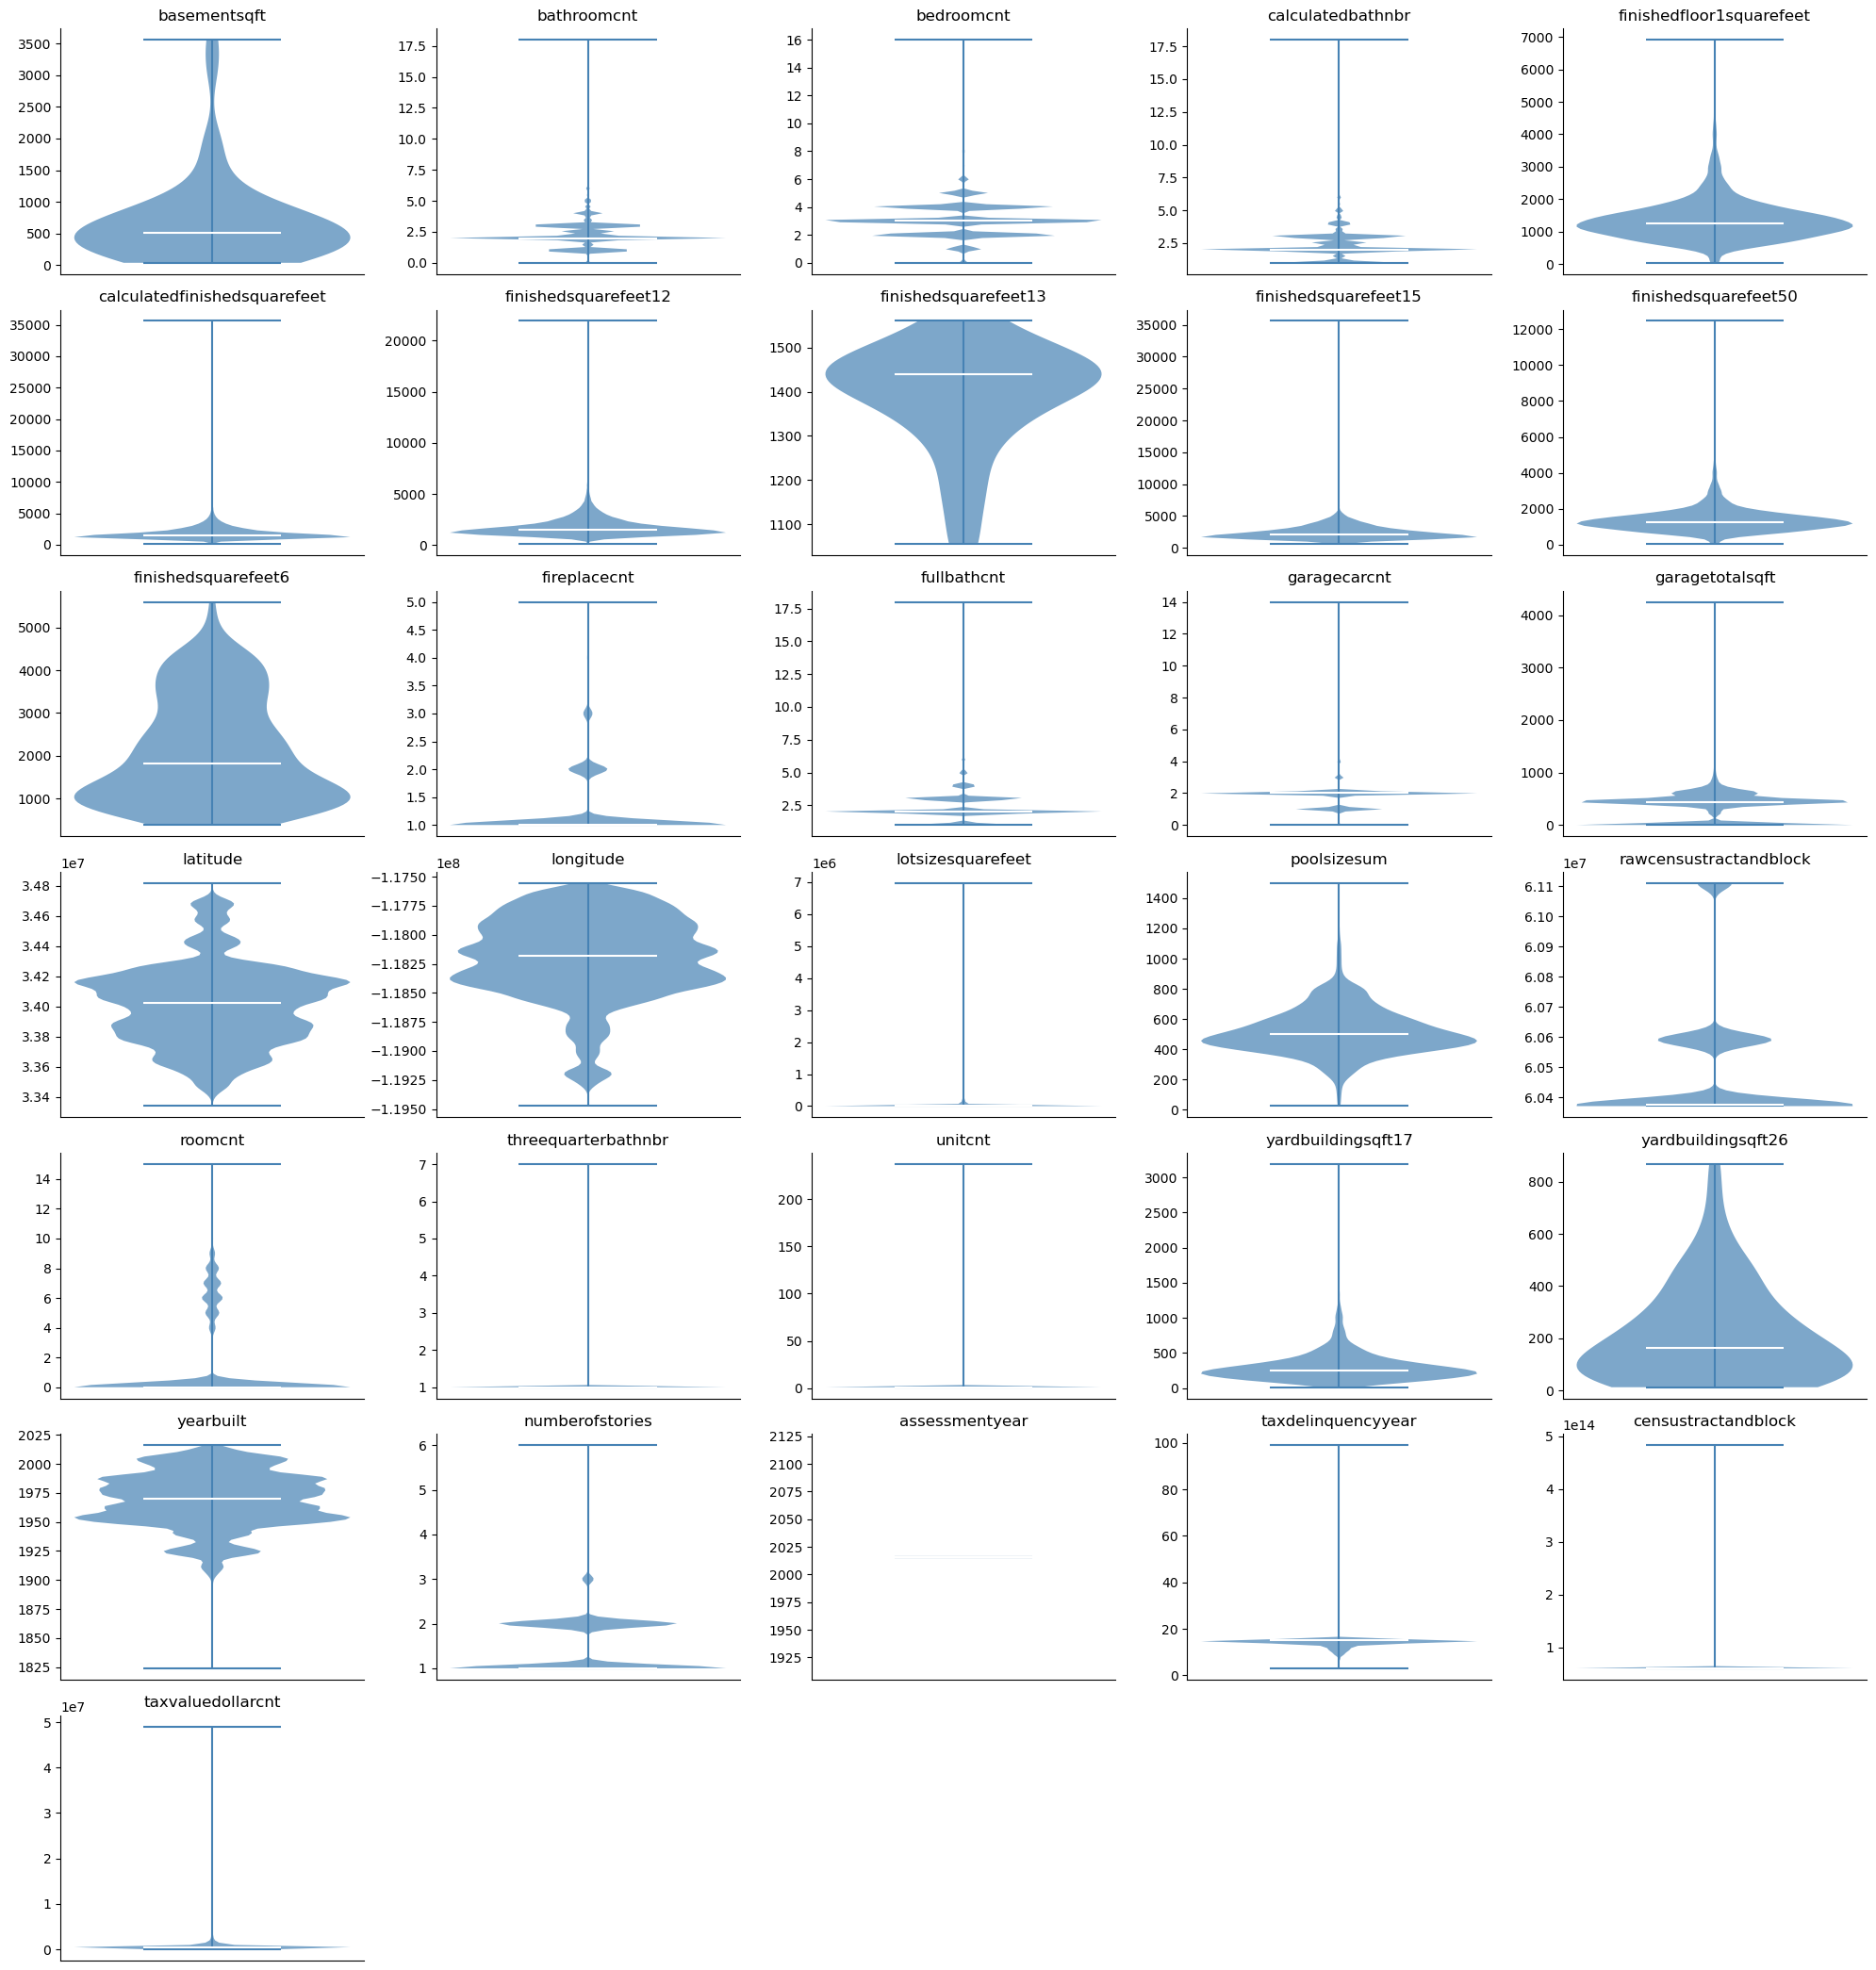

In [6]:
# Violinplots: 
n = len(numerical)
cols = 5
rows = -(-n // cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
axes = axes.flatten()

for i, col in enumerate(numerical):
    parts = axes[i].violinplot(df[col].dropna(), showmedians=True)
    
    # Style the violin
    for pc in parts['bodies']:
        pc.set_facecolor('steelblue')
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('white')
    parts['cmins'].set_color('steelblue')
    parts['cmaxes'].set_color('steelblue')
    parts['cbars'].set_color('steelblue')

    axes[i].set_title(col)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].set_xticks([])  # x tick isn't meaningful for single violins

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
plt.show()

- **Target** (**taxvaluedollarcnt**): right skewed with many outliers, which should be removed in during data cleanup. The bulk of values cluster below $1M, but the tail extends to ~$49M.
- **finishedsquarefeet** variants have different skews and outliers. Once cleaned or combined, outliers should be reexamined. calculatedfinishedsquarefeet and finishedsquarefeet12 look nearly identical, reinforcing the redundancy finding from data quality analysis.
- **finishedsquarefeet13** and **yearbuilt** are the only left-skewed numerical columns (longitude is left-skewed but reflects geography, not a meaningful distribution pattern).
- **decktypeid**: std = 0.0, all non-null values are 66 — a constant, confirmed in the zero-variance analysis from data quality analysis.
- **yardbuildingsqft** has multiple columns, both right skewed with the vast majority of values being very small.
- **assessmentyear** has only 1 value (2016), can be dropped — zero variance, no predictive value.
- **roomcnt**: the 75th percentile is 0, meaning most values are zero. This is suspicious for "total room count" and may indicate the field was not reliably populated or uses a non-obvious definition.
- **garagetotalsqft** shows a bimodal distribution — a peak at 0 (no garage) and a second peak around 400–500 sqft — suggesting it may be useful to convert this into a binary has_garage feature plus a garage_size feature.
- **bathroomcnt** and **bedroomcnt**: max values of 18 and 16 respectively are likely outliers or multi-unit properties that should be investigated during cleaning.

## 2. Deep-Dive: Target Feature — `taxvaluedollarcnt`

The target variable deserves special attention: distribution shape, outliers, and range.

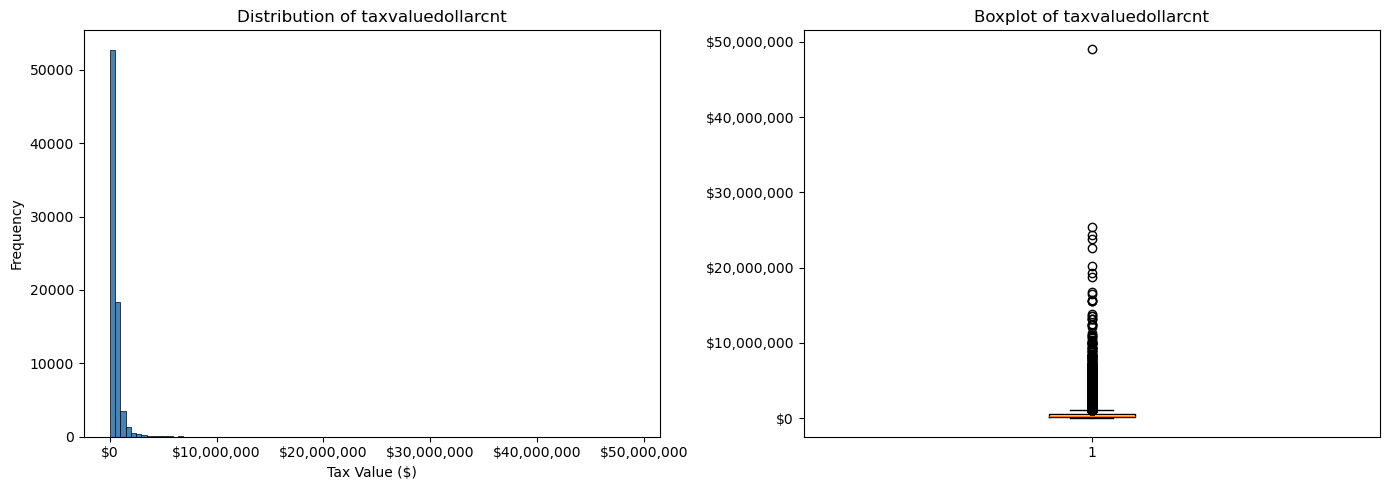

count    7.757800e+04
mean     4.901506e+05
std      6.537979e+05
min      1.000000e+03
25%      2.068985e+05
50%      3.588785e+05
75%      5.690000e+05
max      4.906124e+07
Name: taxvaluedollarcnt, dtype: float64


In [7]:
# Target deep dive:

target = "taxvaluedollarcnt"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram:
axes[0].hist(df[target].dropna(), bins=100, edgecolor='black', linewidth=0.5, color='steelblue')
axes[0].set_title(f"Distribution of {target}")
axes[0].set_xlabel("Tax Value ($)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

# boxplot:
axes[1].boxplot(df[target].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {target}")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.tight_layout()
plt.show()

print(df[target].describe())

1.46% are outliers, excluded from this histogram


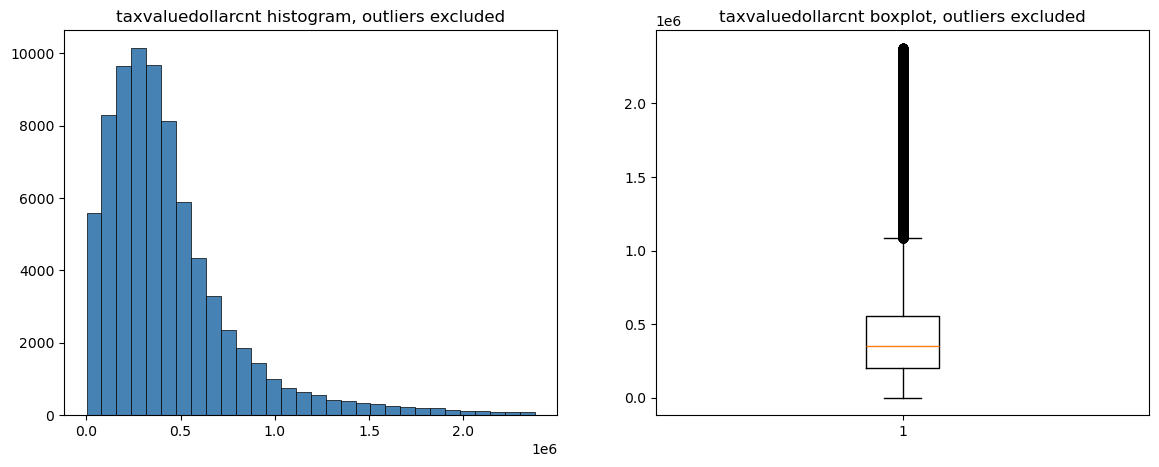

In [8]:
# Target deep dive, outliers removed:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# calculate outlier cutoff, defined by Q3 + x*IQR:
IQR = df[target].quantile(0.75) - df[target].quantile(0.25)
uppercutoff = df[target].quantile(0.75) + 5*IQR
lowercutoff = df[target].quantile(0.25) - 5*IQR

# create mask to exclude left and right-side outliers:
mask = (df[target] > lowercutoff) & (df[target] < uppercutoff)
no_outliers = df[mask]

# calculate % outliers:
target_outliers = abs(no_outliers.shape[0] / df[target].shape[0] - 1)*100
print(f"{target_outliers:.2f}% are outliers, excluded from this histogram")

# plot histogram:
axes[0].hist(no_outliers[target].dropna(), bins=30, edgecolor='black', linewidth=0.5, color='steelblue')
axes[0].set_title(f'{target} histogram, outliers excluded')
# show distance from mean on x-axis

# plot boxplot:
axes[1].boxplot(no_outliers[target].dropna(), vert=True)
axes[1].set_title(f'{target} boxplot, outliers excluded')

None


- **Distribution shape**: The distribution is unimodal and heavily right-skewed. There is a peak at ~$270,000 and an exponential tail.
- **Outliers**: Using the quartiles method, 1.46% of the values are outliers (5k data points).
- **Range**: The minimum is $1,000, and the maximum value (an outlier) is $49,061,240.

## 3. Deep-Dive: Feature 1

Pick an interesting numerical or categorical feature.

**Suggested candidates** (pick one):
- `calculatedfinishedsquarefeet` — total living area, strong predictor candidate
- `yearbuilt` — shows age distribution
- `lotsizesquarefeet` — lot size, potentially skewed

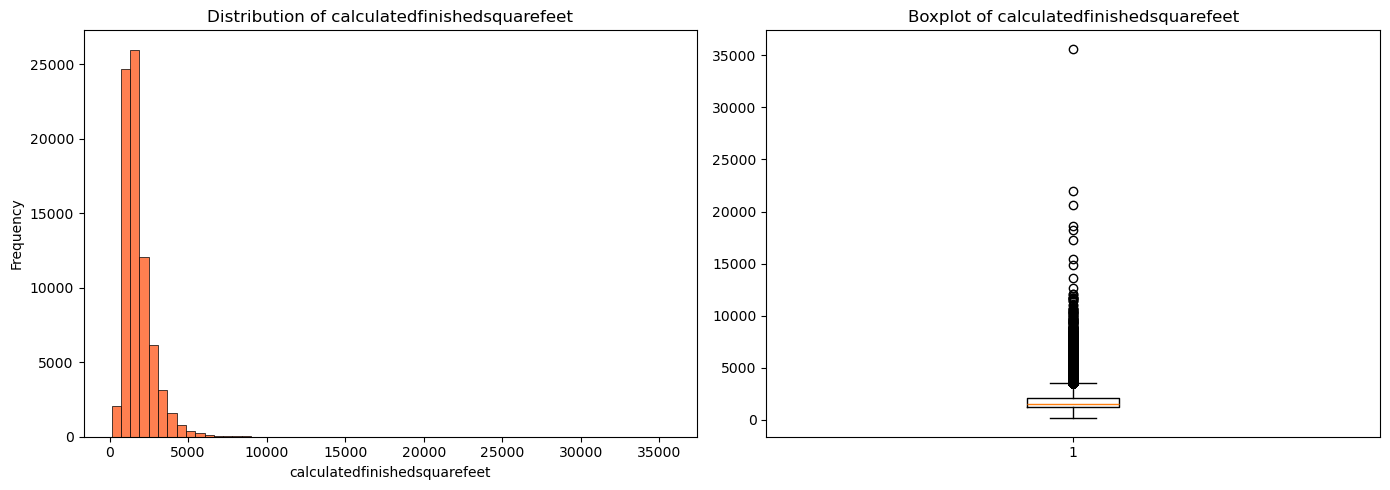

count    77378.000000
mean      1784.935421
std        954.250373
min        128.000000
25%       1182.000000
50%       1542.000000
75%       2112.000000
max      35640.000000
Name: calculatedfinishedsquarefeet, dtype: float64


In [9]:
# Feature 1 deep dive:

feature_1 = "calculatedfinishedsquarefeet"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram:
axes[0].hist(df[feature_1].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='coral')
axes[0].set_title(f"Distribution of {feature_1}")
axes[0].set_xlabel(feature_1)
axes[0].set_ylabel("Frequency")

# boxplot:
axes[1].boxplot(df[feature_1].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_1}")

plt.tight_layout()
plt.show()

print(df[feature_1].describe())

0.47% are outliers, excluded from this histogram


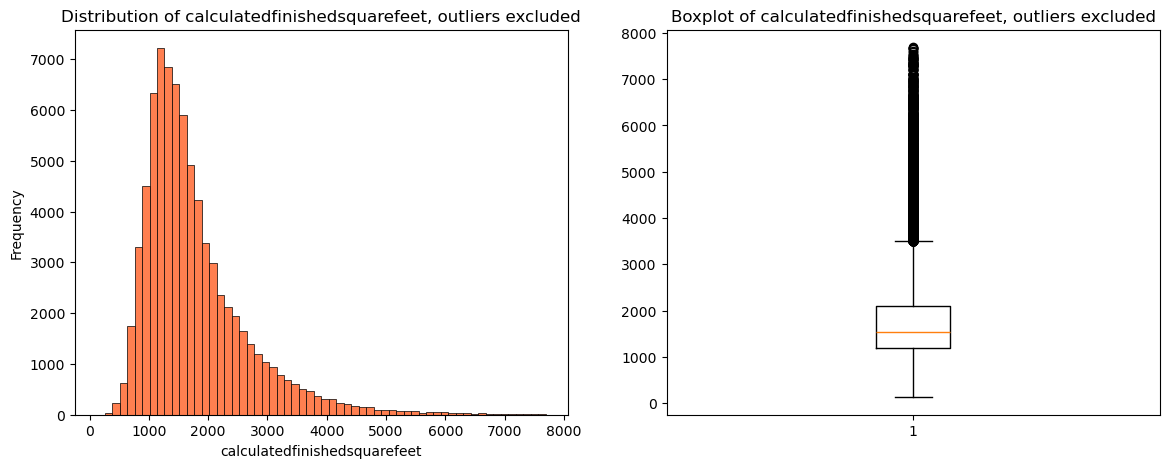

In [10]:
# Feature 1 deep dive, outliers removed:

# calculate outlier cutoff, defined by Q3 + 1.5IQR:
IQR = df[feature_1].quantile(0.75) - df[feature_1].quantile(0.25)
uppercutoff = df[feature_1].quantile(0.75) + 6*IQR
lowercutoff = df[feature_1].quantile(0.25) - 6*IQR

# create mask to exclude left and right-side outliers:
mask = (df[feature_1] > lowercutoff) & (df[feature_1] < uppercutoff)
no_outliers = df[mask]

# calculate % outliers:
feature_1_outliers = abs(no_outliers.shape[0] / df[feature_1].shape[0] - 1)*100
print(f"{feature_1_outliers:.2f}% are outliers, excluded from this histogram")

# plot histogram:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(no_outliers[feature_1].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='coral')
axes[0].set_title(f"Distribution of {feature_1}, outliers excluded")
axes[0].set_xlabel(feature_1)
axes[0].set_ylabel("Frequency")

# plot boxplot
axes[1].boxplot(no_outliers[feature_1].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_1}, outliers excluded")

plt.show()

## 4. Deep-Dive: Feature 2

Pick a second interesting feature.

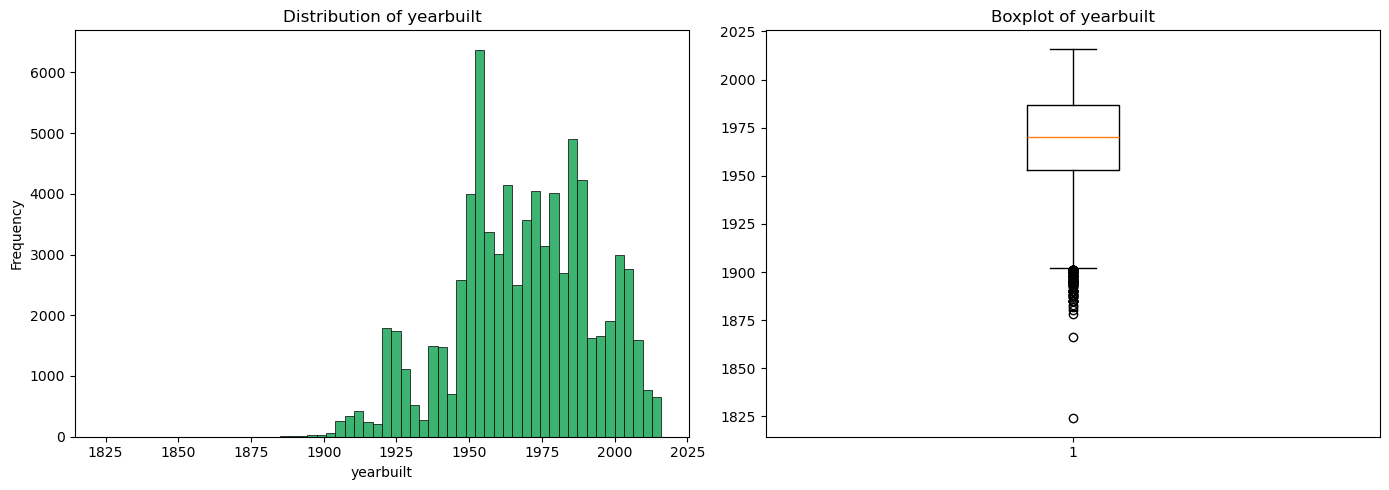

count    77309.000000
mean      1968.611507
std         23.793171
min       1824.000000
25%       1953.000000
50%       1970.000000
75%       1987.000000
max       2016.000000
Name: yearbuilt, dtype: float64


In [11]:
# Feature 2 deep dive:

feature_2 = "yearbuilt"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram:
axes[0].hist(df[feature_2].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='mediumseagreen')
axes[0].set_title(f"Distribution of {feature_2}")
axes[0].set_xlabel(feature_2)
axes[0].set_ylabel("Frequency")

# boxplot:
axes[1].boxplot(df[feature_2].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_2}")

plt.tight_layout()
plt.show()

print(df[feature_2].describe())

0.39% are outliers, excluded from this histogram


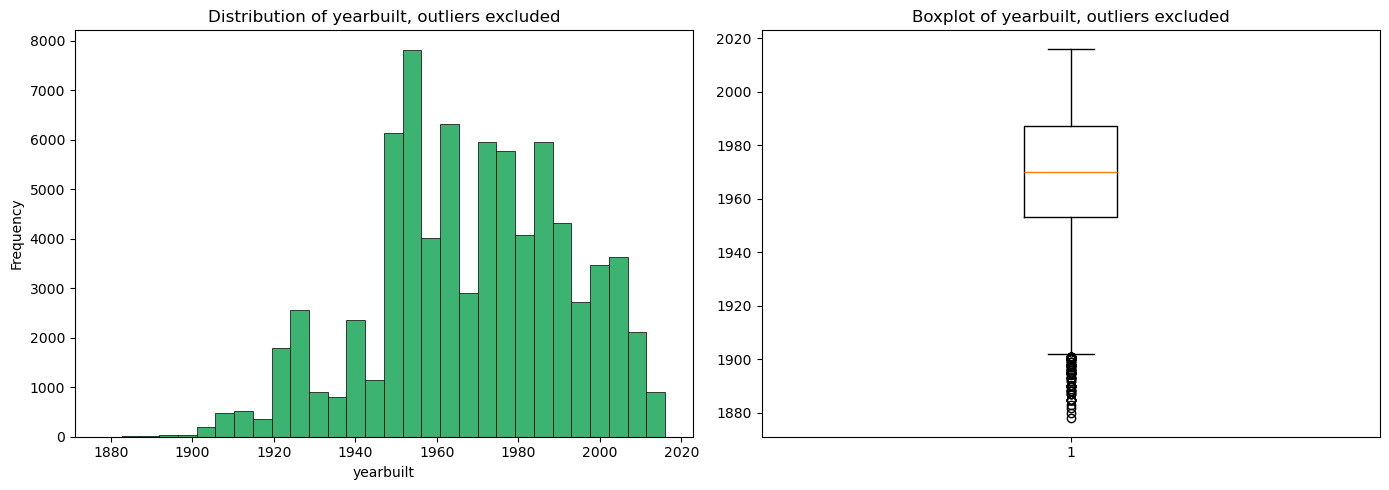

count    77309.000000
mean      1968.611507
std         23.793171
min       1824.000000
25%       1953.000000
50%       1970.000000
75%       1987.000000
max       2016.000000
Name: yearbuilt, dtype: float64


In [12]:
# Feature 2 deep dive, outliers removed:

# calculate outlier cutoff, defined by Q3 + 1.5IQR:
IQR = df[feature_2].quantile(0.75) - df[feature_2].quantile(0.25)
uppercutoff = df[feature_2].quantile(0.75) + 2.5*IQR
lowercutoff = df[feature_2].quantile(0.25) - 2.5*IQR

# create mask to exclude left and right-side outliers:
mask = (df[feature_2] > lowercutoff) & (df[feature_2] < uppercutoff)
no_outliers = df[mask]

# calculate % outliers:
feature_2_outliers = abs(no_outliers.shape[0] / df[feature_2].shape[0] - 1)*100
print(f"{feature_2_outliers:.2f}% are outliers, excluded from this histogram")

# plot:
feature_2 = "yearbuilt"  # <-- CHANGE IF DESIRED

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(no_outliers[feature_2].dropna(), bins=30, edgecolor='black', linewidth=0.5, color='mediumseagreen')
axes[0].set_title(f"Distribution of {feature_2}, outliers excluded")
axes[0].set_xlabel(feature_2)
axes[0].set_ylabel("Frequency")

axes[1].boxplot(no_outliers[feature_2].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_2}, outliers excluded")

plt.tight_layout()
plt.show()

print(df[feature_2].describe())

## 5. Deep-Dive: Feature 3

Pick a third interesting feature. Consider a **categorical** one if you haven't yet.

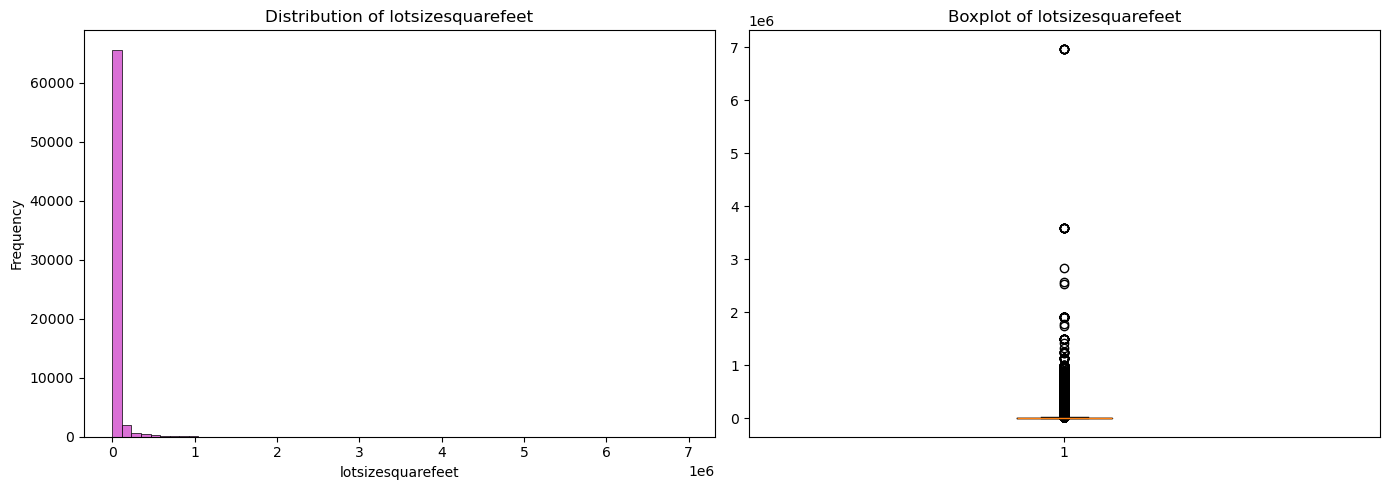

count    6.932100e+04
mean     2.997344e+04
std      1.233050e+05
min      2.360000e+02
25%      5.700000e+03
50%      7.206000e+03
75%      1.183700e+04
max      6.971010e+06
Name: lotsizesquarefeet, dtype: float64


In [13]:
# Feature 3 deep dive:

feature_3 = "lotsizesquarefeet"

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram:
axes[0].hist(df[feature_3].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='orchid')
axes[0].set_title(f"Distribution of {feature_3}")
axes[0].set_xlabel(feature_3)
axes[0].set_ylabel("Frequency")

# boxplot:
axes[1].boxplot(df[feature_3].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {feature_3}")

plt.tight_layout()
plt.show()

print(df[feature_3].describe())

12.72% are outliers, excluded from this histogram


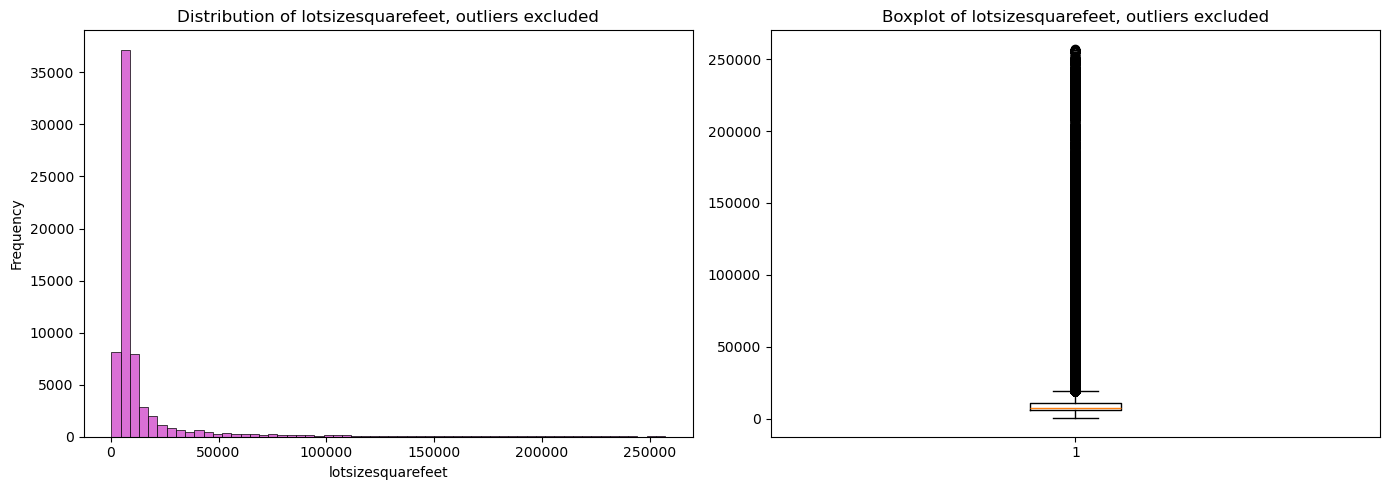

count    6.932100e+04
mean     2.997344e+04
std      1.233050e+05
min      2.360000e+02
25%      5.700000e+03
50%      7.206000e+03
75%      1.183700e+04
max      6.971010e+06
Name: lotsizesquarefeet, dtype: float64


In [14]:
# Feature 3 deep dive, outliers removed:

# calculate outlier cutoff, defined by Q3 + 1.5IQR:
IQR = df[feature_3].quantile(0.75) - df[feature_3].quantile(0.25)
uppercutoff = df[feature_3].quantile(0.75) + 40*IQR
lowercutoff = df[feature_3].quantile(0.25) - 40*IQR

# create mask to exclude left and right-side outliers:
mask = (df[feature_3] > lowercutoff) & (df[feature_3] < uppercutoff)
no_outliers = df[mask]

# calculate % outliers:
feature_3_outliers = abs(no_outliers.shape[0] / df[feature_3].shape[0] - 1)*100
print(f"{feature_3_outliers:.2f}% are outliers, excluded from this histogram")

# plot:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(no_outliers[feature_3].dropna(), bins=60, edgecolor='black', linewidth=0.5, color='orchid')
axes[0].set_title(f"Distribution of {feature_3}, outliers excluded")
axes[0].set_xlabel(feature_3)
axes[0].set_ylabel("Frequency")

axes[1].boxplot(no_outliers[feature_3])
axes[1].set_title(f"Boxplot of {feature_3}, outliers excluded")

plt.tight_layout()
plt.show()

print(df[feature_3].describe())

---
## Discussion Question 2.B

Describe in a paragraph what you learned from your detailed examination:

### **Distribution type** (normal, exponential, skewed, bimodal)?

Most numerical columns are closer to a normal, unimodal distribution, with a right skew.
Only 3 numerical columns have a left skew, 2 of which are significant numerically: yearbuilt, taxdelinquencyyear.
Asessment year and pool count only have 1 possible value. Assessment year can be dropped since every value is 2016. Pool count has 1 or null, and the nulls can be imputed as 0, or the column dropped since the related column poolsizesum can represent existence of pool as well.

### **Problems** (outliers, odd characteristics)?
#### Categorical columns
**Non-boolean features**: parcelid, airconditioningtypeid, architecturalstyletypeid, buildingclasstypeid, buildingqulitytypeid, fips, heatingorsystemtypeid, propertylandusetypeid, regionidcity, regionidcounty, regionidneighborhood, regionidzip, taxdelinquencyyear
- taxdelinquencyyear says "year" but is categorically encoded

**Boolean features**: pooltypeid10, pooltypeid2, pooltypeid7
- Boolean but odd format: decktypeid and storytypeid look boolean but marked at 66 and 7 instead of 1.

#### Numerical columns
Evey numerical column except assessment year and pool count has outliers that will need to be removed in 03.
Many roomcnt values are 0, which is not be possible. Threequarterbathnbedroom also has many 0s, which is impossible, or the definition is different than expected.

#### **Why you chose each feature** and anything interesting?

0. **taxvaluedollarcnt**: This is the target variable. The distribution is unimodal and heavily right-skewed. There is a peak at ~$270,000 and an exponential tail. The minimum is $1,000, and the maximum value (an outlier) is $49,061,240.

1. **calculatedfinishedsquarefeet**: Contextually, finished square feet should be correlated to sale price and the target variable, tax value. It is extremely right-skewed. Removing outliers shows the remaining distribution is unimodal with an exponential distribution, indicating it may be useful to transform exponentially or logarithmically. It has a peak at ~1200 and maintains the right skew.

2. **yearbuilt**: Contextually, age of house is also typically related to sale price and therefore tax value. This is one of the only left skewed features. With outliers removed, the remaining distribution shows a bimodal shape, with peaks around 1920 and 1955. It maintains the left skew. If this feature is important for predicting the target, the bimodal distribution may indicate that an appropriate model will be one that uses clustering or mutliple dimensions, rather than a simple linear regression.

3. **lotsizesquarefeet**: Similar to calculated finished square feet, overall lot size should be correlated to sale price and tax value in context. Again, this is extremely right skewed. It has a peak ~10,000. With outliers removed, the distribution is unimodal with an exponential distribution, indicating it may be useful to transform exponentially or logarithmically. It maintains the right skew.
---

### Next Notebook → `03_data_cleaning.ipynb`